In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ICIWstyle")

In [4]:
n_dot = np.load("MGA-E-05032025_75ml-min_Analytik_MS_composition.npy")
timestamps = np.load("MGA-E-05032025_75ml-min_Analytik_MS_times.npy")

The switching times are ordered in reverse (ie. the index i) is the time at which the i-th-to last switch happened.

In [5]:
switching_periods = np.array(
    [
        45.15,
        45.06,
        44.96,
        45.05,
        45.05,
        45.05,
        45.21,
        45.11,
        45.08,
        45.06,
    ]
)
switching_times = np.flip(np.cumsum(-switching_periods))
switching_times = np.append(switching_times, 0)
print(switching_times)

[-450.78 -405.72 -360.64 -315.53 -270.32 -225.27 -180.22 -135.17  -90.21
  -45.15    0.  ]


In [6]:
intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
intervals

[(-450.78000000000003, -405.72),
 (-405.72, -360.64000000000004),
 (-360.64000000000004, -315.53000000000003),
 (-315.53000000000003, -270.32000000000005),
 (-270.32000000000005, -225.27000000000004),
 (-225.27000000000004, -180.22000000000003),
 (-180.22000000000003, -135.17000000000002),
 (-135.17000000000002, -90.21000000000001),
 (-90.21000000000001, -45.15),
 (-45.15, 0.0)]

In [7]:
timestamps = timestamps - timestamps[-1]
time_delta = timestamps.astype("float") * 1e-9


print(time_delta[0] / timestamps.size)
np.savez("MGA-E-05032025_75ml-min_Analytik_MS.npz", n_dot=n_dot, time_delta=time_delta)

t_range = (time_delta.min(), time_delta.max())

-0.28337290242386576


In [8]:
import scipy
import scipy.interpolate

interp_H2 = scipy.interpolate.interp1d(time_delta, n_dot[0], kind="linear")
interp_Ar = scipy.interpolate.interp1d(time_delta, n_dot[1], kind="linear")

interp_H2(-90)

array(2.54270852e-06)

In [9]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot,
    kind="linear",
    fill_value="extrapolate",
)

In [10]:
t = np.linspace(*t_range, 1000)
n_dot_interp = interp(t)

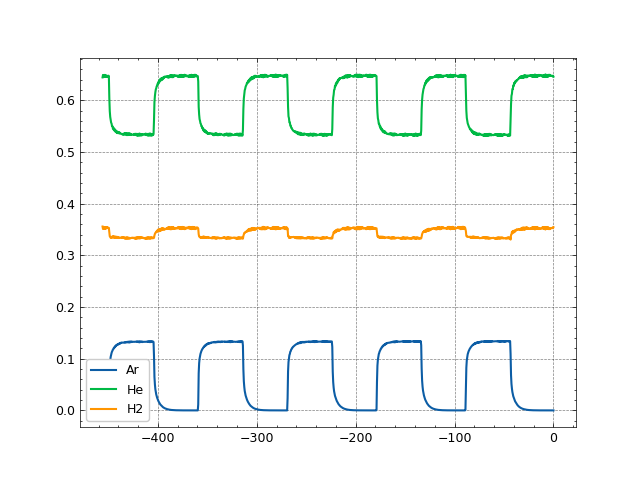

In [11]:
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")
plt.plot(t, n_dot_interp[2], label="H2")
plt.legend()

In [12]:
del n_dots
for interval in intervals:

    t = np.linspace(interval[0], interval[0] + 45, 300)

    n_dot_interp = interp(t)
    print(n_dot_interp[None, :, :].shape)

    plt.plot(t - interval[0], n_dot_interp[[1]].T)
    try:
        n_dots = np.concatenate((n_dots, n_dot_interp[None, :, :]), axis=0)
    except NameError:
        n_dots = n_dot_interp[None, :, :]
print(n_dots.shape)

NameError: name 'n_dots' is not defined

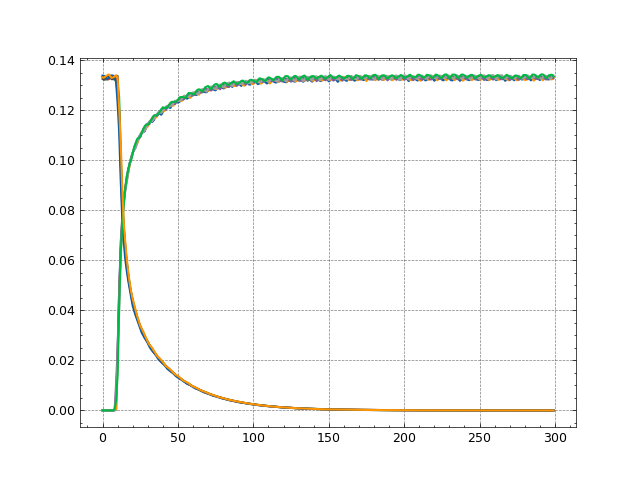

In [ ]:
plt.plot(n_dots[:, 0, :].T)